In [1]:
import numpy as np
from scipy.optimize import linprog

In [2]:
# to impliment: Reznik's discrete probability distribution quantization algorithm  
def quantize_probability(p, l):
    return round(p * (l - 1))/ (l-1) 

In [3]:
def dirac(s):
    mu_i = np.zeros(n)
    idx = np.where(S_n == s)[0][0]
    mu_i[idx] = 1
    return mu_i

In [4]:
def measure_to_state(mu):  #works for any shape of mu (mu_i/mu_k/mu_t)
    #this returns that with the highest probability. we may want to impliment this to return all matches in the future
    return S_n[np.argmax(mu, axis = -1)]

In [5]:
def W2(p, q):
    # note the cost is defined for P(S_n) x P(S_n)
    # p,q have shape mu_i

    c = cost_matrix.flatten()
    
    p_len = len(p)
    q_len = len(q)

    if(c.shape[0] != p_len * q_len):
        print("Ensure that the shape of the inputs match the cost matrix/S_n shape")

    A_eq = np.zeros((p_len + q_len, p_len * q_len))

    #we isolate matrix rows
    for i in range(p_len):
        A_eq[i, i * q_len : (i+1) * q_len] = 1.0

    #we isolate matrix cols
    for j in range(q_len):
        A_eq[p_len + j, j::q_len] = 1.0 

    #rows must equal p, cols must equal q
    b_eq = np.concatenate((p, q))

    result = linprog(c, A_eq = A_eq, b_eq = b_eq, bounds = (0, None), method ='highs')
    return result.fun

In [6]:
def cross_entropy(p, q):
    # note the cost is defined for P(S_n) x P(S_n)
    # p,q have shape mu_i
    q = np.clip(q, 1e-10, 1)
    return -np.sum(p * np.log(q))

In [7]:
#1

# time horizon = number of layers 
T = 2

# probability measure quantization parameter
# (number of quantization levels = number of bins + 1) (ie l = 2 gives {0, 1})
l = 9

#state space quantization parameter
# (number of quantized states = number of bins + 1)
n = 5

#action space_out_out_out quantization parameter
# number of quantized parameters for each action parameter
# quantized actions are within 6 * 1/m distance of the original action (unlike 1/m in paper)
m = 3


In [8]:
#2

def Q_n(s, S_n):
    diffs = np.abs(s - S_n)
    return S_n[np.argmin(diffs)]

# S is the interval [0, 5]
S = (-2.5, 2.5)
#d = 1

#create example quantized state space
S_n = np.linspace(*S, n)

S_n

array([-2.5 , -1.25,  0.  ,  1.25,  2.5 ])

In [9]:
#create ergodic process for data generation

#length of prompt/order of markov chain 
N = 2

#number of training pairs (state labels) 
K_tilde = 18 

#xi=0 is completely non-Markovian, xi=1 is completely Markovian
xi = 1.0

def one_hot(x):
    v = np.zeros(n)
    v[x] = 1
    return v

def generate_process(n, K_tilde, N, xi):
    #generates a process of indices (for the states) 
    
    transition_matrix = np.random.rand(n, n)
    for i in range(n):
        transition_matrix[i] /= np.sum(transition_matrix[i])


    X = [0]
    for r in range(K_tilde + N - 1):
        P1 = np.sum([one_hot(x) @ transition_matrix for x in X[-N:]], axis = 0)
        P2 = np.sum([one_hot(x) @ transition_matrix for x in X[0:-N]], axis = 0)

        P = xi * P1 + (1.0 - xi) * P2
        P = P / P.sum()
        X.append(np.random.choice(n, p=P))
    
    return X


#number of ergodic process samples = K_tilde + N - 1
X = generate_process(n, K_tilde,  N , xi = 1.0)
X

[0, 4, 3, 3, 2, 3, 3, 2, 2, 3, 3, 1, 4, 3, 4, 3, 2, 2, 3, 4]

In [10]:
#split up process into data-label pairs 

def create_pairs(X, S_n, N, K_tilde):
    x = []
    y_tilde = []

    #start at index N
    for r in range(K_tilde - N):
        x.append(S_n[X[r:r+N]])
        y_tilde.append(S_n[X[r + N]])

    #D_tilde = list(zip(x, y_tilde))
    return x, y_tilde

x, y_tilde = create_pairs(X, S_n, N, K_tilde)

In [11]:
cost_matrix = np.array([[np.linalg.norm(s1 - s2)**2 for s1 in S_n] for s2 in S_n]) #used for W2

In [12]:
#3

class Action:
    def __init__(self, W, A, b, Q, K, V, m = None):
        if m is not None:
            W = np.unique(np.linspace(*W, m))
            A = np.unique(np.linspace(*A, m))
            b = np.unique(np.linspace(*b, m))
            Q = np.unique(np.linspace(*Q, m))
            K = np.unique(np.linspace(*K, m))
            V = np.unique(np.linspace(*V, m))
        self.W = W
        self.A = A
        self.b = b
        self.Q = Q
        self.K = K
        self.V = V
    
    def __repr__(self):
        return f"W={self.W}, A={self.A}, b={self.b}, Q={self.Q}, K={self.K}, V={self.V}"

U_m = Action((1, 1), (-2, 2), (-2 , 2), (1,1), (-2,2), (-2, 2), m = m)
beta = 0.3

def create_actions(U):    
    for w_i in U.W:
        for a_i in U.A:
            for b_i in U.b:
                for q_i in U.Q:
                    for k_i in U.K:
                        for v_i in U.V:
                            yield Action(w_i, a_i, b_i, q_i, k_i, v_i)

In [13]:
#4
#assume l > 0
P_l = {i/(l -1) for i in range(0, l)}

def R_l(mu_k):
    quantized = [[quantize_probability(x, l) for x in mu_i] for mu_i in mu_k]
    return quantized
# we have to choose a suitible l given our number of states n or else the probabilities could technically disapear. 
# i think taking l > n suffices, but i have to check

In [14]:
#5-9

def construct_empirical_distribution(x, y_tilde, N, S_n):
    #create empirical distributions, remove duplicates
    K_tilde = len(x)
    mu_0 = []
    y = []
    
    for k in range(K_tilde):
        
        candidate_x = np.array([dirac(Q_n(x[k][i], S_n)) for i in range(N)])
        candidate_y = dirac(Q_n(y_tilde[k], S_n))

        if k > 0:
            matches = np.all(np.all(np.array(mu_0) == candidate_x, axis = 2), axis=1)
        else:
            matches = []

        if np.any(matches):
            idx = np.where(matches == True)[0][0] # we choose the first occurance
            y[idx] += candidate_y
        
        else:
            y.append(candidate_y)
            mu_0.append(candidate_x)

    for k in range(len(y)):
        denom = np.sum(y[k])
        y[k] /= denom
    
    return np.array(mu_0), y

mu_0, y = construct_empirical_distribution(x, y_tilde, N, S_n)

In [15]:
#initialize lifted probability measures
mu = np.zeros((T + 1, *mu_0.shape))
mu[0] = mu_0
#mu has shape (T + 1, K, N, len(S_n))

In [16]:
#10
def relu(x):
    return np.maximum(0, x)

def softmax(x):
    e = np.exp(x)
    return e / e.sum()

def f(s, mu_k, u):

    ff = u.W * relu(u.A * s + u.b)
    
    scores = np.array([s * u.Q * measure_to_state(mu_i) * u.K for mu_i in mu_k])
    weights = softmax(beta * scores)
    attn = np.sum(weights * u.V * np.array([measure_to_state(mu_i) for mu_i in mu_k]))
    
    return np.clip(attn + ff, *S)

def phi_n(u, mu_k):
    result = []
    for mu_i in mu_k:
        s = measure_to_state(mu_i)
        s = Q_n(f(s, mu_k, u), S_n)
        result.append(dirac(s))
    return np.array(result)

def phi(u, mu_t):
    result = []
    for mu_k in mu_t:
        result.append(R_l(phi_n(u, mu_k)))
    return np.array(result)

In [17]:
#11 
def C_T(mu_T, y, loss):
    K_local = len(y)
    total = 0
    for k in range(K_local):
        if loss == 'CE' or loss == 'Cross Entropy':
            total += cross_entropy(mu_T[k][N-1], y[k])
        if loss == 'W2' or loss == 'Wasserstein':
            total += W2(mu_T[k][N-1], y[k])
    return total / K_local
        
def create_reachable_ensembles(target_depth = None):
    #breadth first search with capped depth of T
    count = 0
    visited = {}
    queue = []
    #keep track of ensemble, depth 
    
    start_ens = mu[0]
    start_idx = ensemble_to_index(start_ens)

    visited[0] = {start_idx}
    queue.append((start_ens, 0))

    head = 0
    
    while head < len(queue):
        curr_ens, depth = queue[head]
        head += 1

        if target_depth is None or depth == target_depth:
            yield curr_ens
    
        if depth < T:
            if depth + 1 not in visited:
                visited[depth + 1] = set()
            for u in create_actions(U_m):
                next_ens = phi(u, curr_ens)
                next_idx = ensemble_to_index(next_ens)
                print(count)
                count += 1
                if next_idx not in visited[depth + 1]:
                    visited[depth + 1].add(next_idx)
                    queue.append((next_ens, depth + 1))

def ensemble_to_index(mu_t): 
    state = np.argmax(mu_t, axis = -1).flatten() #look at the S_n axis
    index = sum(int(state[i]) * (n ** i) for i in range(N * len(mu_t)))
    return index

C = {} #for each time step, we find the optimal cost for all reachable states
for t in range(T+1):
    C[t] = {} 

LOSS = 'CE'

for i, mu_T in enumerate(create_reachable_ensembles(target_depth=T)):
    C[T][ensemble_to_index(mu_T)] = C_T(mu_T, y, LOSS)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [18]:
#12 - 17
gamma = {} #for each time step, we find the optimal action for all reachable states
for t in range(T):
    gamma[t] = {}

actions = list(create_actions(U_m))

for t in range(T-1, -1, -1): #goes from T-1 to 0
    for mu_t in create_reachable_ensembles(target_depth=t):
        
        i = ensemble_to_index(mu_t)
        costs = [C[t+1][ensemble_to_index(phi(u, mu_t))] for u in actions] #costs indexed by each action
        best_idx = np.argmin(costs)
        gamma[t][i] = actions[best_idx]
        C[t][i] = np.min(costs)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [19]:
#18 - 24
#Forward pass
U_t = []
for t in range(T): 
    optimal_u = gamma[t][ensemble_to_index(mu[t])]
    mu[t + 1] = phi(optimal_u, mu[t])
    U_t.append(optimal_u)

In [20]:
#25
U_t

[W=1.0, A=2.0, b=0.0, Q=1.0, K=0.0, V=-2.0,
 W=1.0, A=-2.0, b=0.0, Q=1.0, K=2.0, V=2.0]

In [21]:
list(zip((measure_to_state(mu), measure_to_state(y), measure_to_state(mu)[-1, :, 1] - measure_to_state(y))))

[(array([[[-2.5 ,  2.5 ],
          [ 2.5 ,  1.25],
          [ 1.25,  1.25],
          [ 1.25,  0.  ],
          [ 0.  ,  1.25],
          [ 0.  ,  0.  ],
          [ 1.25, -1.25],
          [-1.25,  2.5 ],
          [ 1.25,  2.5 ]],
  
         [[ 0.  ,  2.5 ],
          [ 1.25, -1.25],
          [ 0.  ,  0.  ],
          [ 1.25, -1.25],
          [-1.25,  1.25],
          [ 0.  ,  0.  ],
          [ 2.5 ,  0.  ],
          [-1.25,  2.5 ],
          [-1.25,  1.25]],
  
         [[ 2.5 ,  2.5 ],
          [ 1.25,  1.25],
          [ 0.  ,  0.  ],
          [ 1.25,  1.25],
          [ 1.25,  1.25],
          [ 0.  ,  0.  ],
          [ 2.5 ,  2.5 ],
          [ 0.  ,  2.5 ],
          [ 1.25,  1.25]]]),),
 (array([1.25, 0.  , 0.  , 0.  , 1.25, 1.25, 2.5 , 1.25, 1.25]),),
 (array([ 1.25,  1.25,  0.  ,  1.25,  0.  , -1.25,  0.  ,  1.25,  0.  ]),)]

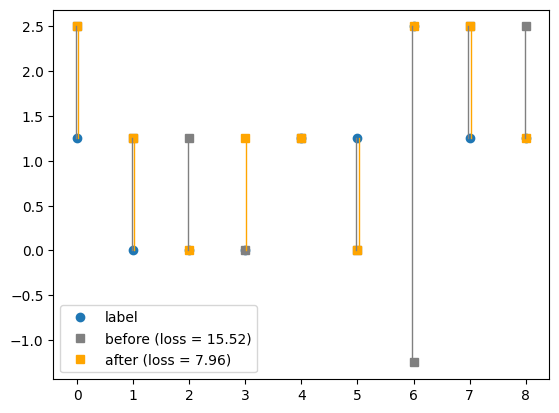

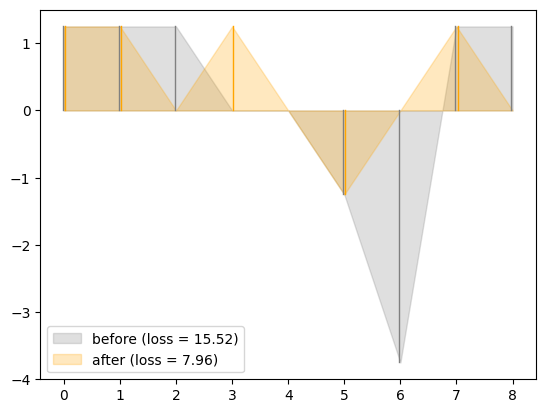

In [22]:
import matplotlib.pyplot as plt

def visualize(mu_arr, y_labels):
    K_viz = len(y_labels)
    before = measure_to_state(mu_arr[0])[:, -1]
    after = measure_to_state(mu_arr[T])[:, -1]
    labels = measure_to_state(np.array(y_labels))

    loss_before = C_T(mu_arr[0], y_labels, LOSS)
    loss_after = C_T(mu_arr[T], y_labels, LOSS)

    plt.plot(labels, 'o', label='label')
    plt.plot(before, 's', label=f'before (loss = {loss_before:.2f})', color='gray')
    plt.plot(after, 's', label=f'after (loss = {loss_after:.2f})', color='orange')

    for k in range(K_viz):
        plt.plot([k-0.02, k-0.02], [before[k], labels[k]], '-', color='gray', lw=1)
        plt.plot([k+0.02, k+0.02], [after[k], labels[k]], '-', color='orange', lw=1)

    plt.legend()
    plt.show()

    plt.fill_between(np.arange(K_viz), before - labels, alpha=0.25, label=f'before (loss = {loss_before:.2f})', color='gray')
    plt.fill_between(np.arange(K_viz), after - labels, alpha=0.25, label=f'after (loss = {loss_after:.2f})', color='orange')

    for k in range(K_viz):
        plt.plot([k-0.02, k-0.02], [(before - labels)[k], 0], color='gray', lw=1)
        plt.plot([k+0.02, k+0.02], [(after - labels)[k], 0], color='orange', lw=1)

    plt.legend()
    plt.show()

visualize(mu, y)


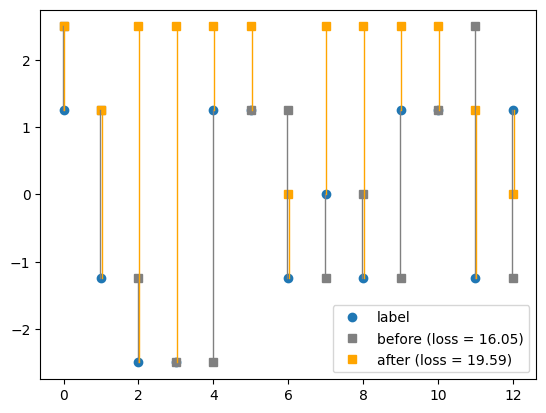

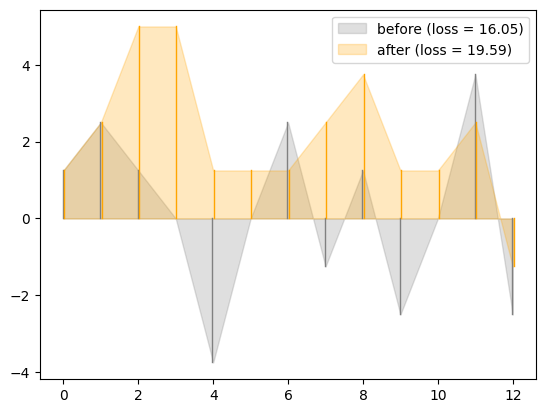

In [23]:
#Testing

X_test = generate_process(n, K_tilde, N, xi=0.5)
x_test, y_tilde_test = create_pairs(X_test, S_n, N, K_tilde)
mu_0_test, y_test = construct_empirical_distribution(x_test, y_tilde_test, N, S_n)

mu_0_test = np.array(mu_0_test)
mu_test = np.zeros((T + 1, *mu_0_test.shape))
mu_test[0] = mu_0_test

#Forward pass
for t in range(T):
    mu_test[t + 1] = phi(U_t[t], mu_test[t])

visualize(mu_test, y_test)
